In [ ]:
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from matplotlib.colors import BoundaryNorm
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

from datasets.data import ERA5MSWX, MSWXDWD, ISIMIP_ERA5

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

## Configuration and Data Loading

In [ ]:
# Configuration
YEARS = [2020, 2021, 2022, 2023]

# Data paths
BASE_PATH = "/data01/FDS/muduchuru/physicsnemo/examples/weather/corrdiff/"
ISIMIP_PATH = "/data01/FDS/muduchuru/Atmos/ISIMIP_ERA5/"

# Define spatial domain (Germany)
LON_MIN, LON_MAX = 5.5, 15.5
LAT_MIN, LAT_MAX = 47.0, 55.5

# Output directory
OUTPUT_DIR = Path('outputs') / 'compound_extremes'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Percentile thresholds for extremes
TEMP_HIGH_PERCENTILE = 90  # Hot days
TEMP_LOW_PERCENTILE = 10   # Cold days
PR_HIGH_PERCENTILE = 95    # Wet days
PR_LOW_PERCENTILE = 20      # Dry days

print(f"Years: {YEARS}")
print(f"Base path: {BASE_PATH}")
print(f"ISIMIP path: {ISIMIP_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Temperature thresholds: P{TEMP_LOW_PERCENTILE}, P{TEMP_HIGH_PERCENTILE}")
print(f"Precipitation thresholds: P{PR_LOW_PERCENTILE}, P{PR_HIGH_PERCENTILE}")

In [ ]:
# Load datasets
print("Loading 10km ERA5-MSWX data...")
era5mswx = ERA5MSWX(base_path=BASE_PATH)
era5mswx.load(YEARS)

print("\nLoading 1km MSWX-DWD data...")
mswxdwd = MSWXDWD(base_path=BASE_PATH)
mswxdwd.load(YEARS)

print("\nLoading ISIMIP BCSD data for precipitation...")
isimip_pr = ISIMIP_ERA5(base_path=ISIMIP_PATH, variable='pr')
isimip_pr.load(YEARS)

print("\nLoading ISIMIP BCSD data for tasmax...")
isimip_tasmax = ISIMIP_ERA5(base_path=ISIMIP_PATH, variable='tasmax')
isimip_tasmax.load(YEARS)

print("\nAll datasets loaded successfully!")

In [ ]:

# Import regridding function from spatial analysis
try:
    import xesmf as xe
    HAS_XESMF = True
except ImportError:
    print("Warning: xesmf not installed.")
    HAS_XESMF = False


def regrid_isimip_to_mswx(isimip_data, mswx_template):
    """Regrid ISIMIP (lat/lon grid) to match MSWX (y/x grid) using xesmf."""
    if not HAS_XESMF:
        print("Error: xesmf not available for regridding")
        return None
    
    try:
        # Extract MSWX's 2D lat/lon coordinates
        mswx_lats = mswx_template.lat.values
        mswx_lons = mswx_template.lon.values
        
        # Create output dataset with proper dimensions (y, x) and coordinates
        ds_out = xr.Dataset({
            'lat': (['y', 'x'], mswx_lats),
            'lon': (['y', 'x'], mswx_lons)
        })
        
        # Create regridder
        regridder = xe.Regridder(isimip_data, ds_out, 'bilinear', periodic=False)
        
        # Apply regridding
        regridded = regridder(isimip_data)
        
        # Add back the time dimension if missing
        if 'time' not in regridded.dims:
            regridded = regridded.expand_dims('time')
        
        # Assign time coordinate from original data
        if 'time' in regridded.coords:
            regridded = regridded.assign_coords(time=isimip_data.time)
        
        # Add MSWX's dimension coordinates
        regridded = regridded.assign_coords(
            y=mswx_template.y,
            x=mswx_template.x
        )
        
        return regridded
        
    except Exception as e:
        print(f"Error regridding ISIMIP to MSWX: {str(e)[:150]}")
        return None


# Regrid ISIMIP to MSWX grid for consistent comparison
print("Regridding ISIMIP data to MSWX grid...")
isimip_pr_regridded = regrid_isimip_to_mswx(isimip_pr.prediction['pr'], era5mswx.truth['pr'])
isimip_tasmax_regridded = regrid_isimip_to_mswx(isimip_tasmax.prediction['tasmax'], era5mswx.truth['tasmax'])

if isimip_pr_regridded is not None:
    print("✓ ISIMIP regridded successfully")
else:
    print("✗ ISIMIP regridding failed")

print("\nDatasets prepared for analysis!")


## Helper Functions for Compound Extreme Analysis and Joint Distributions

In [ ]:

def calculate_joint_distribution_2d(var1, var2, bins=20):
    """
    Calculate 2D joint distribution (histogram) of two variables.
    Computes spatial mean first, then creates 2D histogram of time series.
    
    Parameters:
    -----------
    var1, var2 : xr.DataArray
        Input variables (can be full spatial-temporal data)
    bins : int
        Number of bins for each dimension
    
    Returns:
    --------
    dict : Contains histogram, bin edges, and extent
    """
    # First collapse spatial dimensions to get time series
    spatial_dims_1 = [d for d in var1.dims if d in ['y', 'x', 'lat', 'lon']]
    spatial_dims_2 = [d for d in var2.dims if d in ['y', 'x', 'lat', 'lon']]
    
    if spatial_dims_1:
        var1_ts = var1.mean(dim=spatial_dims_1)
    else:
        var1_ts = var1
    
    if spatial_dims_2:
        var2_ts = var2.mean(dim=spatial_dims_2)
    else:
        var2_ts = var2
    
    # Flatten to 1D arrays
    var1_flat = var1_ts.values.flatten()
    var2_flat = var2_ts.values.flatten()
    
    # Remove NaN values
    valid_idx = ~(np.isnan(var1_flat) | np.isnan(var2_flat))
    var1_flat = var1_flat[valid_idx]
    var2_flat = var2_flat[valid_idx]
    
    if len(var1_flat) == 0:
        print(f"    Warning: No valid data points after NaN filtering")
        return None
    
    # Calculate 2D histogram
    hist, xedges, yedges = np.histogram2d(var1_flat, var2_flat, bins=bins)
    
    return {
        'hist': hist.T,  # Transpose for proper orientation
        'xedges': xedges,
        'yedges': yedges,
        'extent': [xedges[0], xedges[-1], yedges[0], yedges[-1]],
        'var1_range': (np.nanmin(var1_flat), np.nanmax(var1_flat)),
        'var2_range': (np.nanmin(var2_flat), np.nanmax(var2_flat))
    }


def calculate_joint_distribution_difference(model_dist, ref_dist):
    """
    Calculate difference in joint distributions.
    
    Parameters:
    -----------
    model_dist, ref_dist : dict
        Joint distribution dictionaries from calculate_joint_distribution_2d
    
    Returns:
    --------
    dict : Difference histogram and metadata
    """
    if model_dist is None or ref_dist is None:
        return None
    
    # Ensure histograms have same shape by rebinning if necessary
    if model_dist['hist'].shape != ref_dist['hist'].shape:
        print(f"    Warning: Shape mismatch ({model_dist['hist'].shape} vs {ref_dist['hist'].shape})")
        # Use finer bins for interpolation
        return None
    
    diff = model_dist['hist'] - ref_dist['hist']
    
    return {
        'diff': diff,
        'xedges': model_dist['xedges'],
        'yedges': model_dist['yedges'],
        'extent': model_dist['extent'],
        'cmax': np.nanmax(np.abs(diff))
    }


def compute_spatial_mean_timeseries(var):
    """
    Compute spatial mean time series (collapse spatial dimensions).
    """
    spatial_dims = [d for d in var.dims if d in ['lat', 'lon', 'y', 'x']]
    if spatial_dims:
        return var.mean(dim=spatial_dims)
    return var


print("Joint distribution functions defined (updated).")


In [ ]:
def calculate_percentile_threshold(data, percentile):
    """
    Calculate spatial percentile threshold for extreme identification.
    Handles dask arrays by rechunking along time dimension if necessary.
    """
    # Check if data is dask-backed and rechunk if needed
    if hasattr(data, 'chunks') and data.chunks is not None:
        # Rechunk to have a single chunk along time dimension
        data = data.chunk(dict(time=-1))
    
    return data.quantile(percentile/100.0, dim='time')


def identify_hot_dry_events(tasmax, pr, tasmax_threshold, pr_threshold):
    """
    Identify hot-dry compound events where temperature is high AND precipitation is low.
    
    Parameters:
    -----------
    tasmax : xr.DataArray
        Maximum temperature data
    pr : xr.DataArray
        Precipitation data
    tasmax_threshold : xr.DataArray
        Temperature threshold (high temperature for hot days)
    pr_threshold : xr.DataArray
        Precipitation threshold (low precipitation for dry days)
    
    Returns:
    --------
    xr.DataArray : Boolean mask where True indicates hot-dry compound events
    """
    # Create boolean masks for hot and dry conditions
    is_hot = tasmax >= tasmax_threshold
    is_dry = pr <= pr_threshold
    
    # Compound event: both hot AND dry
    compound_events = is_hot & is_dry
    
    return compound_events


def calculate_compound_frequency(compound_events):
    """
    Calculate the frequency (proportion) of compound events across time.
    
    Parameters:
    -----------
    compound_events : xr.DataArray
        Boolean mask of compound events (from identify_hot_dry_events)
    
    Returns:
    --------
    xr.DataArray : Frequency of compound events (0-1 range)
    """
    # Calculate frequency across time dimension
    frequency = compound_events.astype(float).mean(dim='time')
    
    return frequency

## Calculate Thresholds for Each Dataset

In [ ]:
print("Calculating percentile thresholds for extreme identification...\n")

# Store thresholds for each dataset
thresholds = {}

# ERA5MSWX - 10km
print("ERA5MSWX (10km)...")
thresholds['era5'] = {
    'tasmax_high': calculate_percentile_threshold(era5mswx.input['tasmax'], TEMP_HIGH_PERCENTILE),
    'tasmax_low': calculate_percentile_threshold(era5mswx.input['tasmax'], TEMP_LOW_PERCENTILE),
    'pr_high': calculate_percentile_threshold(era5mswx.input['pr'], PR_HIGH_PERCENTILE),
    'pr_low': 1,#calculate_percentile_threshold(era5mswx.input['pr'], PR_LOW_PERCENTILE),
}

thresholds['pred10km'] = {
    'tasmax_high': calculate_percentile_threshold(era5mswx.prediction['tasmax'].isel(ensemble=0), TEMP_HIGH_PERCENTILE),
    'tasmax_low': calculate_percentile_threshold(era5mswx.prediction['tasmax'].isel(ensemble=0), TEMP_LOW_PERCENTILE),
    'pr_high': calculate_percentile_threshold(era5mswx.prediction['pr'].isel(ensemble=0), PR_HIGH_PERCENTILE),
    'pr_low': 1,#calculate_percentile_threshold(era5mswx.prediction['pr'].isel(ensemble=0), PR_LOW_PERCENTILE),
}

thresholds['mswx'] = {
    'tasmax_high': calculate_percentile_threshold(era5mswx.truth['tasmax'], TEMP_HIGH_PERCENTILE),
    'tasmax_low': calculate_percentile_threshold(era5mswx.truth['tasmax'], TEMP_LOW_PERCENTILE),
    'pr_high': calculate_percentile_threshold(era5mswx.truth['pr'], PR_HIGH_PERCENTILE),
    'pr_low': 1,#calculate_percentile_threshold(era5mswx.truth['pr'], PR_LOW_PERCENTILE),
}

# MSWXDWD - 1km
print("MSWXDWD (1km)...")
thresholds['pred1km'] = {
    'tasmax_high': calculate_percentile_threshold(mswxdwd.prediction['tasmax'].isel(ensemble=0), TEMP_HIGH_PERCENTILE),
    'tasmax_low': calculate_percentile_threshold(mswxdwd.prediction['tasmax'].isel(ensemble=0), TEMP_LOW_PERCENTILE),
    'pr_high': calculate_percentile_threshold(mswxdwd.prediction['pr'].isel(ensemble=0), PR_HIGH_PERCENTILE),
    'pr_low': 1,#calculate_percentile_threshold(mswxdwd.prediction['pr'].isel(ensemble=0), PR_LOW_PERCENTILE),
}

thresholds['dwd'] = {
    'tasmax_high': calculate_percentile_threshold(mswxdwd.truth['tasmax'], TEMP_HIGH_PERCENTILE),
    'tasmax_low': calculate_percentile_threshold(mswxdwd.truth['tasmax'], TEMP_LOW_PERCENTILE),
    'pr_high': calculate_percentile_threshold(mswxdwd.truth['pr'], PR_HIGH_PERCENTILE),
    'pr_low': 1,#calculate_percentile_threshold(mswxdwd.truth['pr'], PR_LOW_PERCENTILE),
}

# ISIMIP
print("ISIMIP3BASD...")
isimip_pr_subset = isimip_pr.prediction#.sel(
#     lon=slice(LON_MIN, LON_MAX),
#     lat=slice(LAT_MIN, LAT_MAX)
# )
isimip_tasmax_subset = isimip_tasmax.prediction#.sel(
    # lon=slice(LON_MIN, LON_MAX),
    # lat=slice(LAT_MIN, LAT_MAX)
# )

thresholds['isimip'] = {
    'tasmax_high': calculate_percentile_threshold(isimip_tasmax_subset['tasmax'], TEMP_HIGH_PERCENTILE),
    'tasmax_low': calculate_percentile_threshold(isimip_tasmax_subset['tasmax'], TEMP_LOW_PERCENTILE),
    'pr_high': calculate_percentile_threshold(isimip_pr_subset['pr'], PR_HIGH_PERCENTILE),
    'pr_low': 1,#calculate_percentile_threshold(isimip_pr_subset['pr'], PR_LOW_PERCENTILE),
}

print("\nThresholds calculated for all datasets!")

## Identify Hot-Dry Compound Events

In [ ]:
print("Identifying hot-dry compound events...\n")

# Store compound event masks
hot_dry_events = {}

# ERA5
hot_dry_events['era5'] = identify_hot_dry_events(
    era5mswx.input['tasmax'], 
    era5mswx.input['pr'],
    thresholds['era5']['tasmax_high'],
    thresholds['era5']['pr_low']
)

# Prediction 10km
hot_dry_events['pred10km'] = identify_hot_dry_events(
    era5mswx.prediction['tasmax'].isel(ensemble=0), 
    era5mswx.prediction['pr'].isel(ensemble=0),
    thresholds['pred10km']['tasmax_high'],
    thresholds['pred10km']['pr_low']
)

# MSWX truth
hot_dry_events['mswx'] = identify_hot_dry_events(
    era5mswx.truth['tasmax'], 
    era5mswx.truth['pr'],
    thresholds['mswx']['tasmax_high'],
    thresholds['mswx']['pr_low']
)

# Prediction 1km
hot_dry_events['pred1km'] = identify_hot_dry_events(
    mswxdwd.prediction['tasmax'].isel(ensemble=0), 
    mswxdwd.prediction['pr'].isel(ensemble=0),
    thresholds['pred1km']['tasmax_high'],
    thresholds['pred1km']['pr_low']
)

# DWD truth
hot_dry_events['dwd'] = identify_hot_dry_events(
    mswxdwd.truth['tasmax'], 
    mswxdwd.truth['pr'],
    thresholds['dwd']['tasmax_high'],
    thresholds['dwd']['pr_low']
)

# ISIMIP
hot_dry_events['isimip'] = identify_hot_dry_events(
    isimip_tasmax_subset['tasmax'], 
    isimip_pr_subset['pr'],
    thresholds['isimip']['tasmax_high'],
    thresholds['isimip']['pr_low']
)

print("Hot-dry compound events identified for all datasets!")

In [ ]:
# Print threshold values for all datasets
print("=" * 80)
print("PERCENTILE THRESHOLDS FOR EXTREME IDENTIFICATION")
print("=" * 80)

for dataset_name, threshold_dict in thresholds.items():
    print(f"\n{dataset_name.upper()}:")
    print("-" * 80)
    for threshold_type, threshold_value in threshold_dict.items():
        # Display threshold info without computing (to avoid long dask operations)
        if hasattr(threshold_value, 'shape'):
            print(f"  {threshold_type:20s}: DataArray shape {threshold_value.shape}")
        else:
            try:
                val = float(threshold_value)
                print(f"  {threshold_type:20s}: {val:8.2f}")
            except:
                print(f"  {threshold_type:20s}: <Dask array>")

print("\n" + "=" * 80)
print("Thresholds successfully calculated for:")
for dataset_name in thresholds.keys():
    print(f"  • {dataset_name}")



## Joint Distribution Analysis: Temperature vs Precipitation

In [ ]:

# Prepare data for joint distribution analysis
print("Computing joint distributions of temperature and precipitation...\n")

# Define model-reference pairs matching spatial_extremes_analysis structure
model_ref_pairs = [
    ('ERA5 (~100 km)', era5mswx.input, 'MSWX (10 km)', era5mswx.truth, '10km'),
    ('Prediction (10 km)', era5mswx.prediction.isel(ensemble=0), 'MSWX (10 km)', era5mswx.truth, '10km'),
    ('ISIMIP3BASD (10 km)', {'tasmax': isimip_tasmax_regridded, 'pr': isimip_pr_regridded}, 
     'MSWX (10 km)', era5mswx.truth, '10km'),
]

joint_distributions = {}

for model_name, model_data, ref_name, ref_data, resolution in model_ref_pairs:
    print(f"Processing {model_name} vs {ref_name}...")
    
    pair_key = f"{model_name} vs {ref_name}"
    joint_distributions[pair_key] = {}
    
    # Extract tasmax and pr, handling different data structure formats
    try:
        model_tasmax = model_data['tasmax'] if isinstance(model_data, dict) else model_data['tasmax']
        model_pr = model_data['pr'] if isinstance(model_data, dict) else model_data['pr']
        ref_tasmax = ref_data['tasmax']
        ref_pr = ref_data['pr']
        
        # Calculate joint distributions directly (function handles spatial collapsing)
        # Use fewer bins (8) for smoother distributions
        model_dist = calculate_joint_distribution_2d(model_tasmax, model_pr, bins=8)
        ref_dist = calculate_joint_distribution_2d(ref_tasmax, ref_pr, bins=8)
        
        if model_dist is None or ref_dist is None:
            print(f"  ✗ Failed to compute joint distributions")
            continue
        
        joint_distributions[pair_key]['model'] = model_dist
        joint_distributions[pair_key]['reference'] = ref_dist
        
        # Calculate difference
        diff = calculate_joint_distribution_difference(model_dist, ref_dist)
        if diff is not None:
            joint_distributions[pair_key]['difference'] = diff
        
        print(f"  ✓ Joint distribution computed")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Joint distributions computed for {len(joint_distributions)} model-reference pairs")



## Visualize Joint Distribution Differences

In [ ]:
import colormaps as cmaps
from matplotlib.gridspec import GridSpec

print("Creating joint distribution visualization...\n")

# Count valid pairs first (filter out empty entries from failed computations)
valid_pairs = [(name, data) for name, data in joint_distributions.items() 
               if 'model' in data and 'reference' in data]
n_pairs = len(valid_pairs)

if n_pairs == 0:
    print("✗ No valid joint distributions found. Please check the computation cell output.")
    print(f"   Available keys in joint_distributions: {list(joint_distributions.keys())}")
    for key, val in joint_distributions.items():
        print(f"   {key}: {list(val.keys())}")
else:
    fig, axes = plt.subplots(n_pairs, 3, figsize=(18, 5*n_pairs))

    if n_pairs == 1:
        axes = axes.reshape(1, -1)

    for idx, (pair_name, data) in enumerate(valid_pairs):
        print(f"Plotting {pair_name}...")
        
        model_dist = data['model']
        ref_dist = data['reference']
        
        # Get color map
        cmap_jd = 'Blues'
        cmap_diff = 'RdBu_r'
        
        # --- Column 0: Model Distribution ---
        ax0 = axes[idx, 0]
        im0 = ax0.imshow(model_dist['hist'], extent=model_dist['extent'], 
                        origin='lower', cmap=cmap_jd, aspect='auto')
        ax0.set_xlabel('Temperature (°C)', fontsize=14)
        ax0.set_ylabel('Precipitation (mm/day)', fontsize=14)
        ax0.set_title(f'{pair_name.split(" vs ")[0]} (Model)', fontsize=13, fontweight='bold')
        cbar0 = plt.colorbar(im0, ax=ax0)
        cbar0.set_label('Frequency', fontsize=13)
        cbar0.ax.tick_params(labelsize=12)
        
        # --- Column 1: Reference Distribution ---
        ax1 = axes[idx, 1]
        im1 = ax1.imshow(ref_dist['hist'], extent=ref_dist['extent'],
                        origin='lower', cmap=cmap_jd, aspect='auto')
        ax1.set_xlabel('Temperature (°C)', fontsize=14)
        ax1.set_ylabel('Precipitation (mm/day)', fontsize=14)
        ax1.set_title(f'{pair_name.split(" vs ")[1]}', fontsize=13, fontweight='bold')
        cbar1 = plt.colorbar(im1, ax=ax1)
        cbar1.set_label('Frequency', fontsize=13)
        cbar1.ax.tick_params(labelsize=12)
        
        # --- Column 2: Difference ---
        ax2 = axes[idx, 2]
        if 'difference' in data:
            diff_data = data['difference']
            vmax_diff = diff_data['cmax']
            im2 = ax2.imshow(diff_data['diff'], extent=diff_data['extent'],
                            origin='lower', cmap=cmap_diff, aspect='auto',
                            vmin=-vmax_diff, vmax=vmax_diff)
            ax2.set_xlabel('Temperature (°C)', fontsize=14)
            ax2.set_ylabel('Precipitation (mm/day)', fontsize=14)
            ax2.set_title('Bias', fontsize=13, fontweight='bold')
            cbar2 = plt.colorbar(im2, ax=ax2)
            cbar2.set_label('Δ Frequency', fontsize=13)
            cbar2.ax.tick_params(labelsize=12)
        else:
            ax2.text(0.5, 0.5, 'Difference\nnot computed', 
                    ha='center', va='center', transform=ax2.transAxes,
                    fontsize=14, color='red')
            ax2.set_title('Difference (N/A)', fontsize=12, fontweight='bold')

    plt.suptitle('Joint Distribution Analysis: Temperature vs Precipitation', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    # Save figure
    output_file = OUTPUT_DIR / 'joint_distributions_comparison.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'joint_distributions_comparison.svg', dpi=300)
    print(f"\n✓ Saved: {output_file}")
    plt.show()

print("\nJoint distribution visualization complete!")


Creating 2D KDE contour visualization (MSWX | Models | Bias)...

  ✓ Extracted data for ERA5 (~100 km)
  ✓ Extracted data for Prediction (10 km)
  ✓ Extracted data for ISIMIP3BASD (10 km)
Computing MSWX reference KDE...
Computing KDE for ERA5 (~100 km)...
  ✓ Done: ERA5 (~100 km)
Computing KDE for Prediction (10 km)...
  ✓ Done: Prediction (10 km)
Computing KDE for ISIMIP3BASD (10 km)...
  ✓ Done: ISIMIP3BASD (10 km)

✓ Saved: outputs/compound_extremes/kde_contours_comparison.png


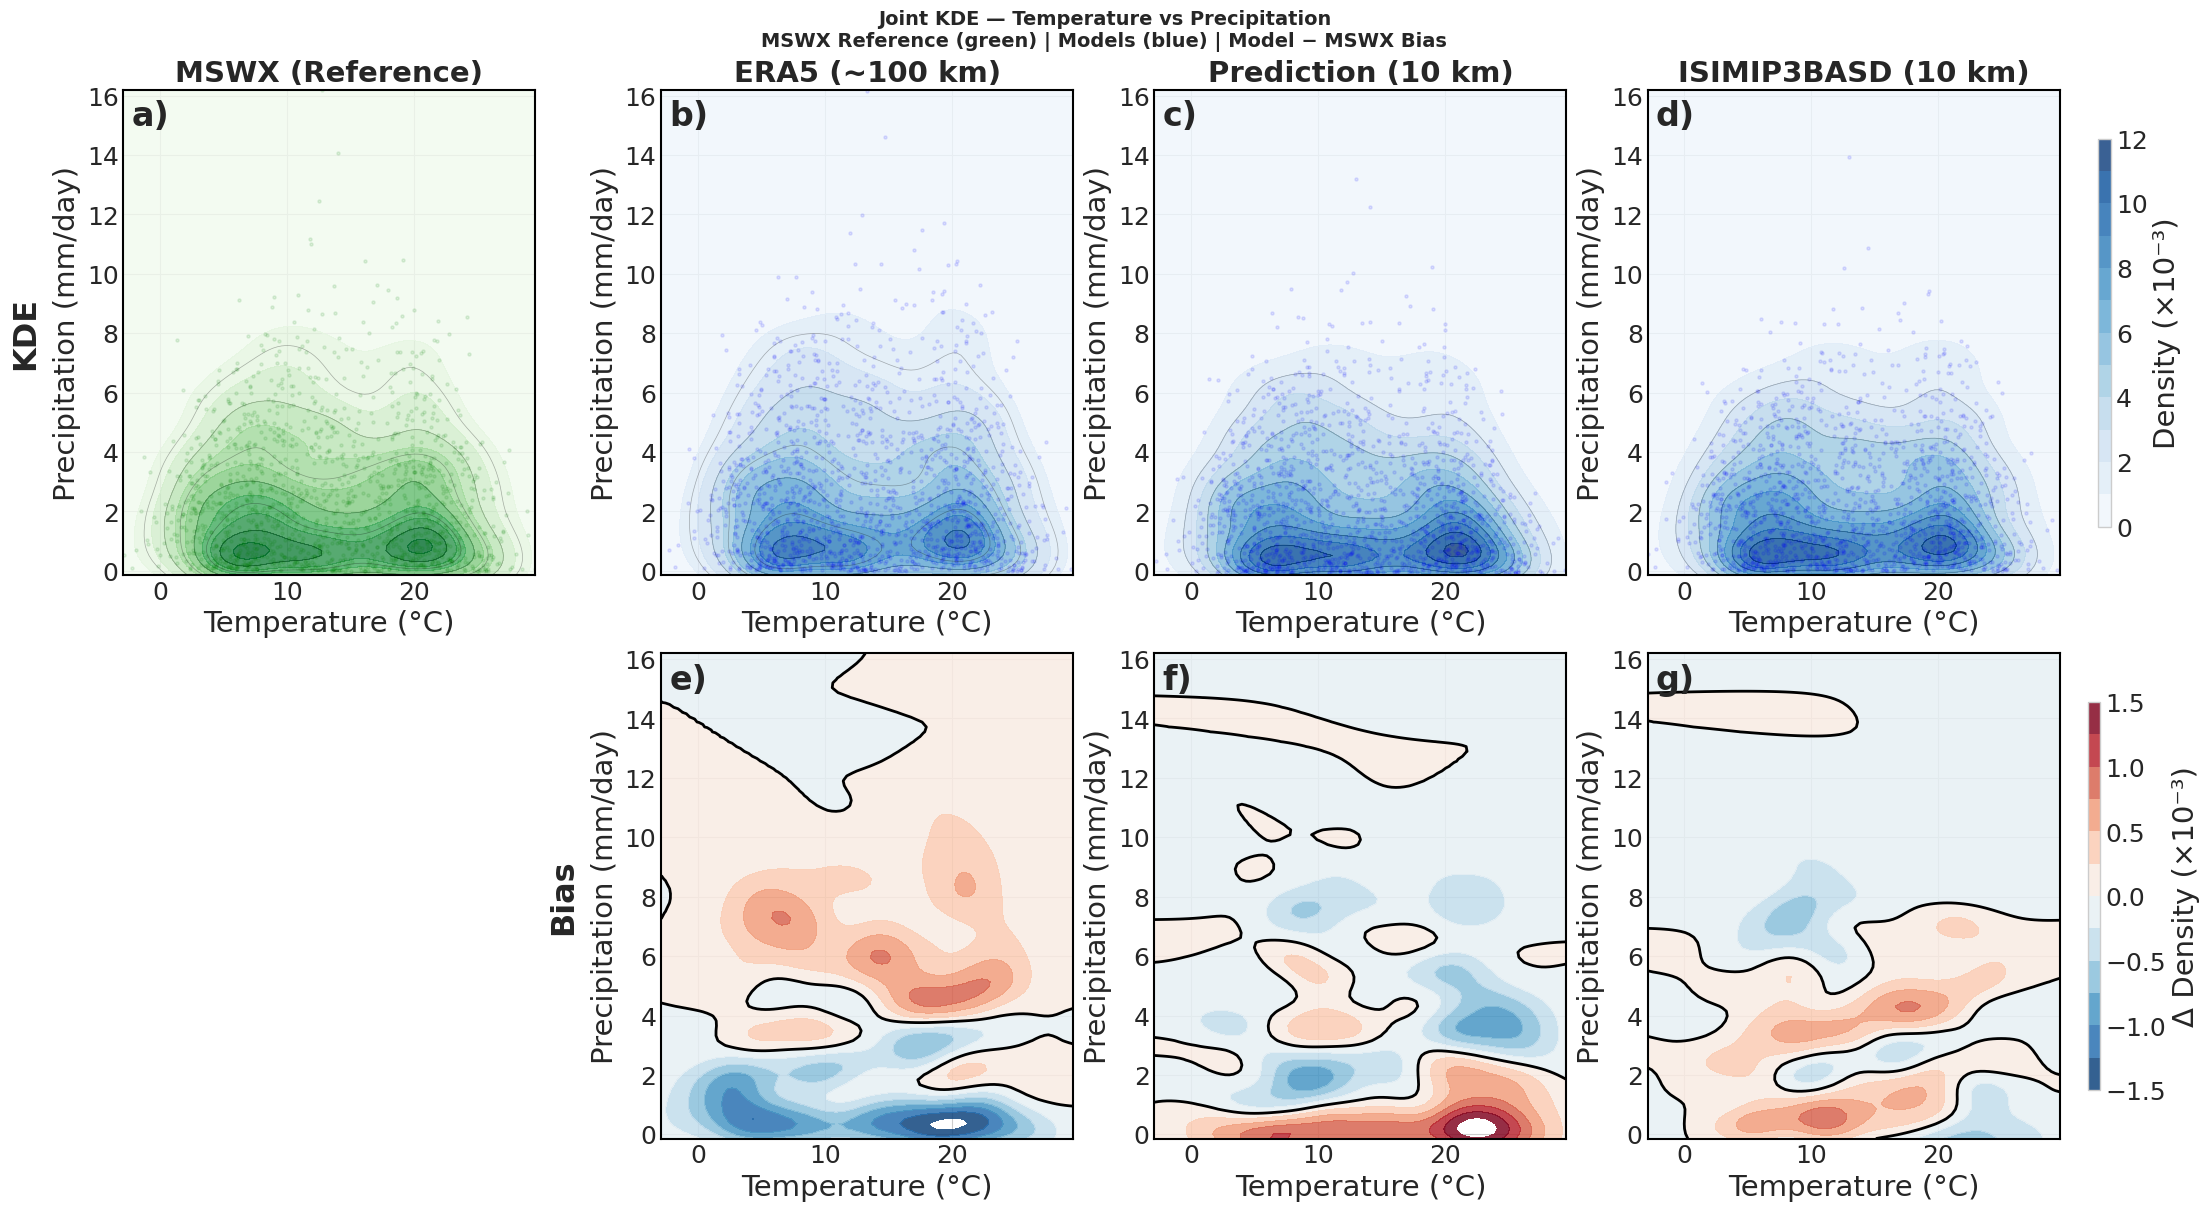


2D KDE contour visualization complete!


In [39]:
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

def add_box(ax, linewidth=1.5, color='black'):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(linewidth)
        spine.set_color(color)

print("Creating 2D KDE contour visualization (MSWX | Models | Bias)...\n")

# Hardcoded scale values
vmax_common = 0.012 * 1000
vmax_diff   = 0.0015 * 1000

# --- Extract data for all models ---
models_data = []
for pair_name, data in valid_pairs:
    for m_name, m_data, r_name, r_data, res in model_ref_pairs:
        if m_name in pair_name:
            try:
                model_tasmax = m_data['tasmax']
                model_pr     = m_data['pr']
                ref_tasmax   = r_data['tasmax']
                ref_pr       = r_data['pr']

                sp_mt = [d for d in model_tasmax.dims if d in ['y', 'x', 'lat']]
                sp_mp = [d for d in model_pr.dims     if d in ['y', 'x', 'lat']]
                sp_rt = [d for d in ref_tasmax.dims   if d in ['y', 'x', 'lat']]
                sp_rp = [d for d in ref_pr.dims       if d in ['y', 'x', 'lat']]

                mt = model_tasmax.mean(dim=sp_mt).values.flatten()
                mp = model_pr.mean(dim=sp_mp).values.flatten()
                rt = ref_tasmax.mean(dim=sp_rt).values.flatten()
                rp = ref_pr.mean(dim=sp_rp).values.flatten()

                valid_m = ~(np.isnan(mt) | np.isnan(mp))
                valid_r = ~(np.isnan(rt) | np.isnan(rp))

                mt, mp = mt[valid_m], mp[valid_m]
                rt, rp = rt[valid_r], rp[valid_r]

                models_data.append({'name': m_name, 'mt': mt, 'mp': mp, 'rt': rt, 'rp': rp})
                print(f"  ✓ Extracted data for {m_name}")
            except Exception as e:
                print(f"  ✗ Error extracting {m_name}: {e}")
            break

if not models_data:
    print("✗ No model data could be extracted.")
else:
    n_models = len(models_data)
    n_cols   = 1 + n_models

    all_t = np.concatenate([d['mt'] for d in models_data] + [models_data[0]['rt']])
    all_p = np.concatenate([d['mp'] for d in models_data] + [models_data[0]['rp']])
    x_min, x_max = all_t.min(), all_t.max()
    y_min, y_max = all_p.min(), all_p.max()

    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])

    levels_common = np.linspace(0, vmax_common, 13)
    levels_diff   = np.linspace(-vmax_diff, vmax_diff, 13)

    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols + 2, 12),
                             constrained_layout=True)

    if n_cols == 1:
        axes = axes.reshape(2, 1)

    # =========================================================
    # Reference KDE
    # =========================================================
    ref_t = models_data[0]['rt']
    ref_p = models_data[0]['rp']

    print("Computing MSWX reference KDE...")
    ref_kde = gaussian_kde(np.vstack([ref_t, ref_p]))
    ref_z   = ref_kde(positions).reshape(xx.shape) * 1e3

    ax_ref = axes[0, 0]
    cs_ref = ax_ref.contourf(xx, yy, ref_z, levels=levels_common, cmap='Greens', alpha=0.8)
    ax_ref.contour(xx, yy, ref_z, levels=6, colors='black', alpha=0.3, linewidths=0.5)
    ax_ref.scatter(ref_t, ref_p, alpha=0.1, s=5, c='green')

    ax_ref.set_xlabel('Temperature (°C)', fontsize=21)
    ax_ref.set_ylabel('Precipitation (mm/day)', fontsize=21)
    ax_ref.set_title('MSWX (Reference)', fontweight='bold', fontsize=21)

    ax_ref.tick_params(axis='both', labelsize=18)

    add_box(ax_ref)
    
    # Add panel label
    ax_ref.text(0.02, 0.98, 'a)', transform=ax_ref.transAxes, 
                fontsize=24, fontweight='bold', va='top', ha='left')

    axes[1, 0].axis('off')

    # =========================================================
    # Models + Bias
    # =========================================================
    for col_idx, d in enumerate(models_data):
        col = col_idx + 1
        letter_idx = col_idx + 1

        print(f"Computing KDE for {d['name']}...")

        model_kde = gaussian_kde(np.vstack([d['mt'], d['mp']]))
        model_z   = model_kde(positions).reshape(xx.shape) * 1e3
        diff_z    = model_z - ref_z

        # --- KDE ---
        ax_m = axes[0, col]
        cs_m = ax_m.contourf(xx, yy, model_z, levels=levels_common, cmap='Blues', alpha=0.8)
        ax_m.contour(xx, yy, model_z, levels=6, colors='black', alpha=0.3, linewidths=0.5)
        ax_m.scatter(d['mt'], d['mp'], alpha=0.1, s=5, c='blue')

        ax_m.set_xlabel('Temperature (°C)', fontsize=21)
        ax_m.set_ylabel('Precipitation (mm/day)', fontsize=21)
        ax_m.set_title(d['name'], fontweight='bold', fontsize=21)

        ax_m.tick_params(axis='both', labelsize=18)

        add_box(ax_m)
        
        # Add panel label
        letter = chr(ord('a') + letter_idx)
        ax_m.text(0.02, 0.98, f'{letter})', transform=ax_m.transAxes, 
                  fontsize=24, fontweight='bold', va='top', ha='left')

        # --- Bias ---
        ax_b = axes[1, col]
        cs_b = ax_b.contourf(xx, yy, diff_z, levels=levels_diff, cmap='RdBu_r', alpha=0.85)
        ax_b.contour(xx, yy, diff_z, levels=[0], colors='black', linewidths=2)

        ax_b.set_xlabel('Temperature (°C)', fontsize=21)
        ax_b.set_ylabel('Precipitation (mm/day)', fontsize=21)
        # ax_b.set_title(f'{d["name"]} − MSWX', fontweight='bold')

        ax_b.tick_params(axis='both', labelsize=18)

        add_box(ax_b)
        
        # Add panel label
        letter = chr(ord('a') + letter_idx + n_models)
        ax_b.text(0.02, 0.98, f'{letter})', transform=ax_b.transAxes,
                  fontsize=24, fontweight='bold', va='top', ha='left')

        print(f"  ✓ Done: {d['name']}")

    # =========================================================
    # Colorbars
    # =========================================================
    cbar_kde = fig.colorbar(cs_m, ax=axes[0, :].tolist(),
                            shrink=0.8, pad=0.02, aspect=30)
    cbar_kde.set_label('Density (×10⁻³)', fontsize=21)
    cbar_kde.ax.tick_params(labelsize=18)

    cbar_bias = fig.colorbar(cs_b, ax=axes[1, 1:].tolist(),
                             shrink=0.8, pad=0.02, aspect=30)
    cbar_bias.set_label('Δ Density (×10⁻³)', fontsize=21)
    cbar_bias.ax.tick_params(labelsize=18)

    # =========================================================
    # Row labels & title
    # =========================================================
    axes[0, 0].annotate('KDE', xy=(-0.2, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=23, fontweight='bold', rotation=90)

    axes[1, 1].annotate('Bias', xy=(-0.2, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=23, fontweight='bold', rotation=90)

    fig.suptitle(
        'Joint KDE — Temperature vs Precipitation\n'
        'MSWX Reference (green) | Models (blue) | Model − MSWX Bias',
        fontsize=14, fontweight='bold'
    )

    output_file = OUTPUT_DIR / 'kde_contours_comparison.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {output_file}")
    plt.show()

print("\n2D KDE contour visualization complete!")

In [38]:
# Print KDE bias statistics for each model vs MSWX reference
print("=" * 70)
print("2D KDE BIAS STATISTICS (Model − MSWX Reference)")
print("=" * 70)

if models_data:
    # Recompute reference KDE (should already be in memory from the plot cell)
    ref_kde_stat = gaussian_kde(np.vstack([models_data[0]['rt'], models_data[0]['rp']]))
    ref_z_stat   = ref_kde_stat(positions).reshape(xx.shape) * 1e3

    for d in models_data:
        model_kde_stat = gaussian_kde(np.vstack([d['mt'], d['mp']]))
        model_z_stat   = model_kde_stat(positions).reshape(xx.shape) * 1e3
        diff_z_stat    = model_z_stat - ref_z_stat

        print(f"\n{d['name']} − MSWX:")
        print(f"  Mean bias        : {diff_z_stat.mean():+.4f}  ×10⁻³")
        print(f"  Std of bias      : {diff_z_stat.std():.4f}   ×10⁻³")
        print(f"  Max positive bias: {diff_z_stat.max():+.4f}  ×10⁻³")
        print(f"  Max negative bias: {diff_z_stat.min():+.4f}  ×10⁻³")
        print(f"  RMSE             : {np.sqrt((diff_z_stat**2).mean()):.4f}   ×10⁻³")
        print(f"  MAE              : {np.abs(diff_z_stat).mean():.4f}   ×10⁻³")

    print("\n" + "=" * 70)
else:
    print("No model data available.")

2D KDE BIAS STATISTICS (Model − MSWX Reference)

ERA5 (~100 km) − MSWX:
  Mean bias        : +0.0061  ×10⁻³
  Std of bias      : 0.3459   ×10⁻³
  Max positive bias: +0.8693  ×10⁻³
  Max negative bias: -1.5771  ×10⁻³
  RMSE             : 0.3460   ×10⁻³
  MAE              : 0.2072   ×10⁻³

Prediction (10 km) − MSWX:
  Mean bias        : -0.0200  ×10⁻³
  Std of bias      : 0.2968   ×10⁻³
  Max positive bias: +1.7132  ×10⁻³
  Max negative bias: -0.9467  ×10⁻³
  RMSE             : 0.2975   ×10⁻³
  MAE              : 0.1608   ×10⁻³

ISIMIP3BASD (10 km) − MSWX:
  Mean bias        : +0.0161  ×10⁻³
  Std of bias      : 0.1995   ×10⁻³
  Max positive bias: +0.9276  ×10⁻³
  Max negative bias: -0.6400  ×10⁻³
  RMSE             : 0.2001   ×10⁻³
  MAE              : 0.1185   ×10⁻³




## Joint Distribution Statistics

In [ ]:
# Compute and display statistical summary of joint distributions
print("Computing joint distribution statistics...\n")
print("=" * 80)

stats_summary = []

for pair_name, data in joint_distributions.items():
    # Skip entries with missing data
    if 'model' not in data or 'reference' not in data:
        print(f"\nSkipping {pair_name}: Missing model or reference data")
        continue
    
    print(f"\n{pair_name}:")
    print("-" * 80)
    
    model_dist = data['model']
    ref_dist = data['reference']

## Visualization: Hot-Dry Compound Event Frequency

In [ ]:
# Calculate frequency for each dataset
hot_dry_freq = {}
for name, events in hot_dry_events.items():
    hot_dry_freq[name] = calculate_compound_frequency(events)

# Create visualization
fig = plt.figure(figsize=(25, 8))
proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
cmap = 'YlOrRd'

datasets_plot = [
    ('ERA5 (~100 km)', 'era5'),
    ('Prediction (10 km)', 'pred10km'),
    ('MSWX (10 km)', 'mswx'),
    # ('Prediction (1 km)', 'pred1km'),
    # ('DWD (1 km)', 'dwd'),
    ('ISIMIP3BASD (10 km)', 'isimip'),
]

lons, lats = era5mswx.input.lon,era5mswx.input.lat
for idx, (title, key) in enumerate(datasets_plot):
    ax = fig.add_subplot(1, 6, idx+1, projection=proj)
    
    data = hot_dry_freq[key]
    

    
    # Plot
    im = ax.pcolormesh(lons, lats, data.values, 
                       transform=proj, cmap=cmap,
                       vmin=0, vmax=0.1, shading='auto')
    
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=1.0)
    # ax.set_extent(extent, crs=proj)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.gridlines(draw_labels=False, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_visible(True)
        spine.set_color('black')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('Frequency', fontsize=13)
    cbar.ax.tick_params(labelsize=12)

plt.suptitle('Hot-Dry Compound Events Frequency', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hot_dry_compound_events.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'hot_dry_compound_events.svg', dpi=300)
plt.show()

print(f"Saved: {OUTPUT_DIR / 'hot_dry_compound_events.png'}")


## Additional Compound Event Types

This section will be developed to include:
- Hot-Wet compound events
- Cold-Wet compound events
- Spatial extent analysis
- Temporal clustering of events
- Comparison with observational datasets

In [ ]:
print("Ready for additional compound extreme analysis...")